
# HAWQ-V3 Implementation — RQNKUP

To summarize:
1. Choose your baseline paper: **HAWQ-V3: Dyadic Neural Network Quantization**
2. Load the dataset(s) and model(s) used (no retraining — everything here is *post-training*, fake-quantized simulation of HAWQ-V3's pipeline; the paper's own numbers use quantization-aware fine-tuning, so expect lower accuracy here, especially at INT4)
3. Understand the quantization pipeline and bit budgeting (ILP)
4. Evaluate the sensitivity metric proposed (Hessian trace)
5. (Bonus) Evaluate other sensitivity metrics (RQNKUP: excess kurtosis, spectral rank)

# 0. Setup

In [1]:
# Install dependencies and clone HAWQ repo (reference only)
!pip install -q pytorchcv pyhessian pulp datasets
!git clone -q https://github.com/Zhen-Dong/HAWQ.git

fatal: destination path 'HAWQ' already exists and is not an empty directory.


In [2]:
# Mount Google Drive to save data and results
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Imports & constants: HF token, project paths, data splits, preprocessing, device
import os, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import TensorDataset, DataLoader

from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

from datasets import load_dataset
from pytorchcv.model_provider import get_model as ptcv_get_model
import pulp

# ---- reproducibility ----
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- device ----
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ---- paths (Google Drive) ----
PROJECT_DIR = "/content/drive/MyDrive/rqnkup/hawqv3"                 # shared: notebook + results
DATA_DIR    = "/content/drive/MyDrive/rqnkup/hawqv3/hawqv3_data"      # shared: the ImageNet subset
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- dataset split sizes (disjoint: eval / hessian / calibration) ----
N_EVAL    = 10_000   # accuracy measurement
N_HESSIAN = 512      # Hessian trace computation (paper: converges beyond ~512 images)
N_CALIB   = 512      # activation range calibration
N_TOTAL   = N_EVAL + N_HESSIAN + N_CALIB

DATA_FILE = os.path.join(DATA_DIR, f"imagenet_val_224_n{N_TOTAL}.pt")

# ---- ImageNet normalization stats (applied on-GPU at batch time, NOT stored) ----
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)

# ---- preprocessing transform: resize->crop->uint8 tensor (standard ImageNet eval recipe) ----
preprocess = T.Compose([
    T.Lambda(lambda img: img.convert("RGB")),
    T.Resize(256),
    T.CenterCrop(224),
    T.PILToTensor(),
])

# ---- quantization / dataloader settings ----
BIT_CHOICES = [4, 8]
BATCH_SIZE = 128

def normalize_batch(uint8_batch):
    """uint8 (B,3,224,224) on CPU -> normalized float32 on DEVICE."""
    x = uint8_batch.to(DEVICE).float() / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x

Using device: cuda


# 1. Dataset(s) used

* **ImageNet (ILSVRC2012) validation set**, streamed from Hugging Face (`ILSVRC/imagenet-1k`).
* We only need the 50,000-image validation set (no retraining), split into three
  **disjoint** groups so evaluation, sensitivity computation, and calibration never
  contaminate each other:
  - `N_EVAL` images for Top-1 accuracy
  - `N_HESSIAN` images for the Hessian-trace sensitivity metric
  - `N_CALIB` images for activation range calibration

In [4]:
# Stream a shuffled ImageNet val subset and save it to Drive (skips if already saved)
if os.path.exists(DATA_FILE):
    print("Subset already saved, skipping download:", DATA_FILE)
else:
    stream = load_dataset("ILSVRC/imagenet-1k", split="validation",
                          streaming=True, token=HF_TOKEN)
    stream = stream.shuffle(seed=SEED, buffer_size=10_000).take(N_TOTAL)

    images, labels = [], []
    for ex in tqdm(stream, total=N_TOTAL, desc="Streaming ImageNet val"):
        images.append(preprocess(ex["image"]))
        labels.append(ex["label"])

    images = torch.stack(images)          # (N, 3, 224, 224) uint8
    labels = torch.tensor(labels)         # (N,)
    torch.save({"images": images, "labels": labels}, DATA_FILE)
    print(f"Saved {len(labels)} images to {DATA_FILE}")

Subset already saved, skipping download: /content/drive/MyDrive/rqnkup/hawqv3/hawqv3_data/imagenet_val_224_n11024.pt


In [5]:
# Load subset back from Drive and split into eval / hessian / calib DataLoaders
data = torch.load(DATA_FILE)
all_images, all_labels = data["images"], data["labels"]
print("Loaded:", all_images.shape, all_images.dtype,
      "| unique classes:", all_labels.unique().numel())

eval_images,    eval_labels    = all_images[:N_EVAL],                 all_labels[:N_EVAL]
hessian_images, hessian_labels = all_images[N_EVAL:N_EVAL+N_HESSIAN],  all_labels[N_EVAL:N_EVAL+N_HESSIAN]
calib_images,   calib_labels   = all_images[N_EVAL+N_HESSIAN:],        all_labels[N_EVAL+N_HESSIAN:]
print("eval:", eval_images.shape, "hessian:", hessian_images.shape, "calib:", calib_images.shape)

eval_loader = DataLoader(TensorDataset(eval_images, eval_labels),
                           batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
hessian_loader = DataLoader(TensorDataset(hessian_images, hessian_labels),
                           batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
calib_loader   = DataLoader(TensorDataset(calib_images, calib_labels),
                           batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Loaded: torch.Size([11024, 3, 224, 224]) torch.uint8 | unique classes: 1000
eval: torch.Size([10000, 3, 224, 224]) hessian: torch.Size([512, 3, 224, 224]) calib: torch.Size([512, 3, 224, 224])


Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

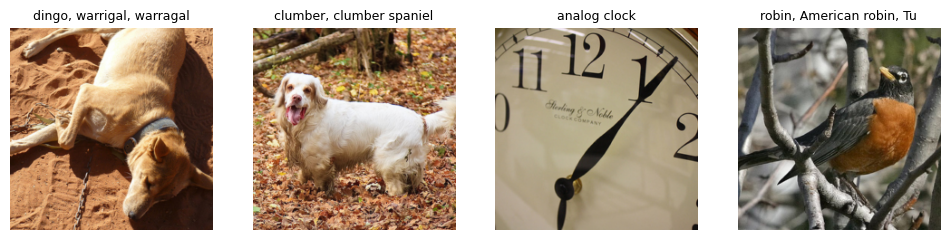

In [6]:
# Sanity check: view a few images with their class names
label_names = load_dataset("ILSVRC/imagenet-1k", split="validation",
                           streaming=True, token=HF_TOKEN).features["label"].int2str

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, i in zip(axes, range(4)):
    ax.imshow(eval_images[i].permute(1, 2, 0))
    ax.set_title(label_names(eval_labels[i].item())[:25], fontsize=9)
    ax.axis("off")
plt.show()

# 2. Model(s) used

* **ResNet-18** first (fast to iterate on), then **ResNet-50** and **Inception-V3** by
  re-running this notebook with `MODEL_NAME` changed (Inception-V3 needs a 299x299
  data file instead of 224x224).
* Pretrained weights come from **PyTorchCV**, which is what the paper used to get its
  strong FP32 baselines (71.47% ResNet-18, 77.72% ResNet-50, 78.88% Inception-V3).
  torchvision's ResNet-18 scores lower (~69.8%) because it's a different training recipe.

In [7]:
# Load a pretrained model and put it in eval mode
MODEL_NAME = "resnet18"   # later: "resnet50", "inceptionv3"
model = ptcv_get_model(MODEL_NAME, pretrained=True).to(DEVICE)
model.eval()
print(f"Loaded {MODEL_NAME}, {sum(p.numel() for p in model.parameters())/1e6:.2f}M params")

Loaded resnet18, 11.69M params


In [8]:
# Evaluate Top-1 accuracy -- this FP32 number is the baseline everything else is compared to
@torch.no_grad()
def evaluate_top1(model, loader, desc="eval"):
    model.eval()
    correct, total = 0, 0
    for images, labels in tqdm(loader, desc=desc):
        x = normalize_batch(images)
        y = labels.to(DEVICE)
        logits = model(x)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.numel()
    return 100.0 * correct / total

fp32_acc = evaluate_top1(model, eval_loader, desc="FP32 baseline")
print(f"FP32 Top-1 accuracy: {fp32_acc:.2f}%  (paper: 71.47% for ResNet-18 / PyTorchCV)")

FP32 baseline:   0%|          | 0/79 [00:00<?, ?it/s]

FP32 Top-1 accuracy: 72.62%  (paper: 71.47% for ResNet-18 / PyTorchCV)


In [9]:
# Layer inventory: every Conv2d / Linear, its parameter count, and its MACs
# (MACs need the layer's OUTPUT shape, captured with a forward hook)
def build_layer_inventory(model, input_size=224):
    layers = {}
    handles = []

    def make_hook(name, module):
        def hook(mod, inputs, output):
            if isinstance(mod, nn.Conv2d):
                out_h, out_w = output.shape[-2], output.shape[-1]
                k_h, k_w = mod.kernel_size
                macs = (mod.out_channels * out_h * out_w *
                        (mod.in_channels // mod.groups) * k_h * k_w)
            else:  # nn.Linear
                macs = mod.in_features * mod.out_features
            layers[name]["macs"] = macs
        return hook

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            layers[name] = {"module": module,
                            "params": sum(p.numel() for p in module.parameters()),
                            "macs": None}
            handles.append(module.register_forward_hook(make_hook(name, module)))

    dummy = torch.zeros(1, 3, input_size, input_size, device=DEVICE)
    with torch.no_grad():
        model(dummy)
    for h in handles:
        h.remove()
    return layers

layer_inventory = build_layer_inventory(model)
layer_names = list(layer_inventory.keys())
first_layer_name, last_layer_name = layer_names[0], layer_names[-1]
print(f"Found {len(layer_names)} quantizable layers")
print("First layer (kept at 8-bit):", first_layer_name)
print("Last layer  (kept at 8-bit):", last_layer_name)

total_params = sum(v["params"] for v in layer_inventory.values())
total_macs   = sum(v["macs"]   for v in layer_inventory.values())
print(f"Total quantizable params: {total_params/1e6:.2f}M "
      f"(~{total_params*4/1024**2:.1f} MB at FP32; paper: 44.6 MB)")
print(f"Total MACs: {total_macs/1e9:.3f} G "
      f"(paper FP32 BOPS = 1858 G = 32*32*MACs -> expected MACs ~= {1858/1024:.2f} G)")

Found 21 quantizable layers
First layer (kept at 8-bit): features.init_block.conv.conv
Last layer  (kept at 8-bit): output
Total quantizable params: 11.68M (~44.6 MB at FP32; paper: 44.6 MB)
Total MACs: 1.814 G (paper FP32 BOPS = 1858 G = 32*32*MACs -> expected MACs ~= 1.81 G)


# 3. Sensitivity metric(s)

**Paper's metric (HAWQ-V2, reused by HAWQ-V3):**
Omega_i = avg_trace(H_i) * ||Q(W_i) - W_i||^2 -- the average Hessian trace (how "bumpy"
the loss is around layer i's weights) times the squared quantization perturbation
(how much quantizing layer i actually changes its weights).

The trace is estimated with **Hutchinson's method**: for random +-1 vectors z,
E[z^T H z] = Tr(H). We get the Hessian-vector product Hz via double backprop
(`torch.autograd.grad` with `create_graph=True`), without ever forming the full
Hessian matrix.

**Baselines we compare against:**
* HAWQ-V1's **top Hessian eigenvalue** (power iteration) instead of the trace
* **Quantization error only**, with no Hessian weighting at all
* **Random** per-layer scores, as a sanity-check floor

In [10]:
# Hutchinson's method: average Hessian trace per layer (HAWQ-V2 / PyHessian style)
# Processes ONE BATCH AT A TIME and discards each graph immediately, since
# Hz of an averaged loss == the average of each batch's own Hz (linearity).
# This keeps peak memory to one batch's worth, instead of all batches at once.
def compute_layer_hessian_traces(model, layer_names, loader, n_iters=30):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    weights = [layer_inventory[name]["module"].weight for name in layer_names]
    n_batches = len(loader)

    trace_sums = {name: 0.0 for name in layer_names}

    for it in tqdm(range(n_iters), desc="Hutchinson iterations"):
        # same random z's for every batch this iteration (needed for the averaging trick)
        zs = [torch.randint(0, 2, w.shape, device=DEVICE).float() * 2 - 1 for w in weights]
        Hz_accum = [torch.zeros_like(w) for w in weights]

        for x, y in loader:
            x, y = normalize_batch(x), y.to(DEVICE)
            loss = criterion(model(x), y)

            grads = torch.autograd.grad(loss, weights, create_graph=True)
            gz = sum((g * z).sum() for g, z in zip(grads, zs))
            Hzs = torch.autograd.grad(gz, weights)  # no create_graph needed here

            for i, Hz in enumerate(Hzs):
                Hz_accum[i] += Hz.detach()

            del loss, grads, gz, Hzs
            torch.cuda.empty_cache()

        for name, z, Hz_sum in zip(layer_names, zs, Hz_accum):
            Hz_avg = Hz_sum / n_batches
            trace_sums[name] += (z * Hz_avg).sum().item()

    traces = {}
    for name in layer_names:
        n_params = layer_inventory[name]["params"]
        traces[name] = trace_sums[name] / n_iters / n_params
    return traces

hessian_traces = compute_layer_hessian_traces(model, layer_names, hessian_loader, n_iters=10)

Hutchinson iterations:   0%|          | 0/10 [00:00<?, ?it/s]

In [11]:
vals = np.array(list(hessian_traces.values()))
print(f"trace: min={vals.min():.6f} max={vals.max():.6f} std={vals.std():.6f} mean={vals.mean():.6f}")

trace: min=0.000771 max=0.224993 std=0.048685 mean=0.024191


In [12]:
# Fake-quantize a weight tensor: symmetric, per-output-channel (matches HAWQ-V3)
def fake_quantize_symmetric_per_channel(weight, bits):
    out_ch = weight.shape[0]
    w = weight.detach().reshape(out_ch, -1)
    max_val = w.abs().max(dim=1, keepdim=True).values.clamp(min=1e-8)
    qmax = 2 ** (bits - 1) - 1
    scale = max_val / qmax
    q = torch.clamp(torch.round(w / scale), -qmax - 1, qmax)
    w_hat = q * scale
    return w_hat.reshape(weight.shape)

# Combine trace * perturbation -> Omega_i^(bits) for each bit choice
def compute_omega(layer_inventory, hessian_traces, bit_choices=BIT_CHOICES):
    omega = {}
    for name, info in layer_inventory.items():
        weight = info["module"].weight.detach()
        trace = hessian_traces[name]
        omega[name] = {}
        for b in bit_choices:
            w_hat = fake_quantize_symmetric_per_channel(weight, b)
            perturb = (w_hat - weight).pow(2).sum().item()
            omega[name][b] = trace * perturb
    return omega

omega = compute_omega(layer_inventory, hessian_traces)

In [13]:
# Baseline 1: HAWQ-V1's top Hessian eigenvalue per layer, via power iteration
# Processes one batch at a time and averages Hv across batches each step,
# rather than summing all batches' losses before differentiating (which OOMs).
def compute_top_eigenvalue(model, layer_names, loader, n_iters=20):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    n_batches = len(loader)
    eigs = {}

    for name in tqdm(layer_names, desc="Top eigenvalue per layer"):
        weight = layer_inventory[name]["module"].weight
        v = torch.randn_like(weight)
        v = v / v.norm()
        eigenvalue = 0.0

        for _ in range(n_iters):
            Hv_accum = torch.zeros_like(weight)

            for x, y in loader:
                x, y = normalize_batch(x), y.to(DEVICE)
                loss = criterion(model(x), y)

                grad = torch.autograd.grad(loss, weight, create_graph=True)[0]
                gv = (grad * v).sum()
                Hv = torch.autograd.grad(gv, weight)[0]

                Hv_accum += Hv.detach()

                del loss, grad, gv, Hv
                torch.cuda.empty_cache()

            Hv_avg = Hv_accum / n_batches
            eigenvalue = (v * Hv_avg).sum().item()
            v = Hv_avg / (Hv_avg.norm() + 1e-12)

        eigs[name] = eigenvalue
    return eigs

top_eigs = compute_top_eigenvalue(model, layer_names, hessian_loader, n_iters=20)

Top eigenvalue per layer:   0%|          | 0/21 [00:00<?, ?it/s]

In [14]:
# Baseline 2 & 3: quantization error with no Hessian weighting at all, and random scores
def compute_baseline_metrics(layer_inventory, bit_choices=BIT_CHOICES):
    quant_error_only = {}
    random_scores = {}
    rng = np.random.default_rng(SEED)
    for name, info in layer_inventory.items():
        weight = info["module"].weight.detach()
        quant_error_only[name] = {}
        for b in bit_choices:
            w_hat = fake_quantize_symmetric_per_channel(weight, b)
            quant_error_only[name][b] = (w_hat - weight).pow(2).sum().item()
        random_scores[name] = float(rng.random())
    return quant_error_only, random_scores

quant_error_only, random_scores = compute_baseline_metrics(layer_inventory)

# fold the top eigenvalue and random score into the SAME per-bit Omega shape,
# using the same quantization-perturbation term so only the sensitivity differs
top_eig_omega = {n: {b: top_eigs[n] * quant_error_only[n][b] for b in BIT_CHOICES} for n in layer_names}
random_omega  = {n: {b: random_scores[n] * quant_error_only[n][b] for b in BIT_CHOICES} for n in layer_names}

# 4. !! MOST IMPORTANT !! Quantization pipeline & bit budgeting (ILP)

**Quantization pipeline (simulated / fake-quant, since TVM integer kernels aren't
available in Colab):**
* Weights: symmetric, per-channel quantization
* Activations: asymmetric, per-layer quantization, using ranges calibrated on
  `calib_loader` with momentum 0.99 (matches the paper's static quantization)
* First and last layer are always forced to 8-bit, regardless of what the ILP picks

**Bit budgeting:** the paper poses bit-width selection as an Integer Linear Program --
minimize total perturbation `sum_i Omega_i^(bi)` subject to a model-size (or BOPS, or
latency) budget. We solve it with **PuLP**, the same library the paper used.

In [15]:
# Activation range calibration: track each layer's output min/max over the calib set
def calibrate_activation_ranges(model, layer_names, loader, momentum=0.99):
    ranges = {name: {"min": None, "max": None} for name in layer_names}
    handles = []

    def make_hook(name):
        def hook(mod, inputs, output):
            batch_min = output.detach().min().item()
            batch_max = output.detach().max().item()
            r = ranges[name]
            if r["min"] is None:
                r["min"], r["max"] = batch_min, batch_max
            else:
                r["min"] = momentum * r["min"] + (1 - momentum) * batch_min
                r["max"] = momentum * r["max"] + (1 - momentum) * batch_max
        return hook

    for name in layer_names:
        module = layer_inventory[name]["module"]
        handles.append(module.register_forward_hook(make_hook(name)))

    model.eval()
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Calibrating activations"):
            model(normalize_batch(x))
    for h in handles:
        h.remove()
    return ranges

activation_ranges = calibrate_activation_ranges(model, layer_names, calib_loader)

Calibrating activations:   0%|          | 0/4 [00:00<?, ?it/s]

In [16]:
# Fake-quantize activations (asymmetric, using the calibrated range)
def fake_quantize_activation(x, bits, act_min, act_max):
    qmax = 2 ** bits - 1
    scale = max((act_max - act_min) / qmax, 1e-8)
    zero_point = round(-act_min / scale)
    q = torch.clamp(torch.round(x / scale) + zero_point, 0, qmax)
    x_hat = (q - zero_point) * scale
    return x_hat

class FakeQuantWrapper(nn.Module):
    """Wraps a Conv2d/Linear with weight + output-activation fake quant.
    Mutates the wrapped module's weight.data in place each forward call;
    the ORIGINAL weight is kept in self._orig_weight for restoring later."""
    def __init__(self, module, bits, act_min, act_max):
        super().__init__()
        self.module = module
        self.bits = bits
        self.act_min = act_min
        self.act_max = act_max
        self._orig_weight = module.weight.data.clone()

    def forward(self, x):
        self.module.weight.data = fake_quantize_symmetric_per_channel(
            self._orig_weight, self.bits)
        out = self.module(x)
        out = fake_quantize_activation(out, self.bits, self.act_min, self.act_max)
        return out

def get_parent_module(model, name):
    parts = name.split(".")
    parent = model
    for p in parts[:-1]:
        parent = getattr(parent, p)
    return parent, parts[-1]

def apply_bit_config(model, bit_config, activation_ranges, first_layer_name, last_layer_name):
    """bit_config: dict layer_name -> bits. First/last layer forced to 8 regardless."""
    handles = []
    for name in layer_names:
        bits = 8 if name in (first_layer_name, last_layer_name) else bit_config[name]
        module = layer_inventory[name]["module"]
        r = activation_ranges[name]
        parent, attr = get_parent_module(model, name)
        wrapped = FakeQuantWrapper(module, bits, r["min"], r["max"])
        setattr(parent, attr, wrapped)
        handles.append((parent, attr, wrapped))
    return handles

def restore_model(handles):
    for parent, attr, wrapped in handles:
        wrapped.module.weight.data = wrapped._orig_weight
        setattr(parent, attr, wrapped.module)

In [17]:
# Model size (MB) and BOPS (G) for a given bit config
def model_size_mb(bit_config, first_layer_name, last_layer_name):
    total_bits = 0
    for name, info in layer_inventory.items():
        bits = 8 if name in (first_layer_name, last_layer_name) else bit_config[name]
        total_bits += info["params"] * bits
    return total_bits / 8 / 1024**2

def model_bops_g(bit_config, first_layer_name, last_layer_name):
    total = 0
    for name, info in layer_inventory.items():
        bits = 8 if name in (first_layer_name, last_layer_name) else bit_config[name]
        total += (bits ** 2) * info["macs"]     # weight bits == activation bits in HAWQ-V3
    return total / 1e9

In [18]:
# The ILP: minimize total perturbation subject to a model-size budget
def solve_ilp(omega, layer_inventory, bit_choices, size_limit_mb=None, bops_limit_g=None,
              first_layer_name=None, last_layer_name=None):
    free_layers = [n for n in layer_inventory if n not in (first_layer_name, last_layer_name)]
    prob = pulp.LpProblem("HAWQ_bit_allocation", pulp.LpMinimize)

    x = {(n, b): pulp.LpVariable(f"x_{n}_{b}", cat="Binary")
         for n in free_layers for b in bit_choices}

    prob += pulp.lpSum(omega[n][b] * x[(n, b)] for n in free_layers for b in bit_choices)

    for n in free_layers:
        prob += pulp.lpSum(x[(n, b)] for b in bit_choices) == 1

    if size_limit_mb is not None:
        fixed_mb = sum(layer_inventory[n]["params"] * 8 for n in (first_layer_name, last_layer_name)) / 8 / 1024**2
        prob += fixed_mb + pulp.lpSum(
            (layer_inventory[n]["params"] * b / 8 / 1024**2) * x[(n, b)]
            for n in free_layers for b in bit_choices
        ) <= size_limit_mb

    if bops_limit_g is not None:
        fixed_bops = sum((8 ** 2) * layer_inventory[n]["macs"] for n in (first_layer_name, last_layer_name)) / 1e9
        prob += fixed_bops + pulp.lpSum(
            ((b ** 2) * layer_inventory[n]["macs"] / 1e9) * x[(n, b)]
            for n in free_layers for b in bit_choices
        ) <= bops_limit_g

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    bit_config = {first_layer_name: 8, last_layer_name: 8}
    for n in free_layers:
        for b in bit_choices:
            if pulp.value(x[(n, b)]) > 0.5:
                bit_config[n] = b
    return bit_config, pulp.LpStatus[prob.status]

# 5. Evaluate the model

Metrics: Top-1 accuracy, model size (MB), and BOPS (G). We compare uniform INT8,
uniform INT4, and mixed-precision under a matching size budget for each sensitivity
metric (Hessian trace, top eigenvalue, quantization-error-only, and random).

In [19]:
# Uniform INT8 and uniform INT4
def make_uniform_bit_config(layer_names, bits):
    return {n: bits for n in layer_names}

results = []
for bits in BIT_CHOICES:
    bit_config = make_uniform_bit_config(layer_names, bits)
    handles = apply_bit_config(model, bit_config, activation_ranges,
                               first_layer_name, last_layer_name)
    acc = evaluate_top1(model, eval_loader, desc=f"Uniform INT{bits}")
    restore_model(handles)

    results.append({
        "method": f"Uniform INT{bits}",
        "top1": acc,
        "size_mb": model_size_mb(bit_config, first_layer_name, last_layer_name),
        "bops_g": model_bops_g(bit_config, first_layer_name, last_layer_name),
    })

pd.DataFrame(results)

Uniform INT4:   0%|          | 0/79 [00:00<?, ?it/s]

Uniform INT8:   0%|          | 0/79 [00:00<?, ?it/s]

,method,top1,size_mb,bops_g
0,Uniform INT4,1.76,5.818520,34.714419
1,Uniform INT8,72.61,11.138832,116.100694


In [20]:
# Mixed precision at a size budget roughly midway between uniform INT4 and INT8
int4_size = next(r["size_mb"] for r in results if r["method"] == "Uniform INT4")
int8_size = next(r["size_mb"] for r in results if r["method"] == "Uniform INT8")
mid_size_limit = (int4_size + int8_size) / 2
print(f"INT4 size: {int4_size:.2f} MB | INT8 size: {int8_size:.2f} MB | "
      f"mixed-precision budget: {mid_size_limit:.2f} MB")

def evaluate_sensitivity_metric(name, omega, size_limit_mb):
    bit_config, status = solve_ilp(omega, layer_inventory, BIT_CHOICES,
                                   size_limit_mb=size_limit_mb,
                                   first_layer_name=first_layer_name,
                                   last_layer_name=last_layer_name)
    print(f"[{name}] ILP status: {status}")

    handles = apply_bit_config(model, bit_config, activation_ranges,
                               first_layer_name, last_layer_name)
    acc = evaluate_top1(model, eval_loader, desc=f"Mixed ({name})")
    restore_model(handles)

    return {
        "method": f"Mixed ({name})",
        "bit_config": bit_config,
        "top1": acc,
        "size_mb": model_size_mb(bit_config, first_layer_name, last_layer_name),
        "bops_g": model_bops_g(bit_config, first_layer_name, last_layer_name),
    }

hessian_result = evaluate_sensitivity_metric("Hessian trace (HAWQ-V3)", omega, mid_size_limit)
results.append(hessian_result)

INT4 size: 5.82 MB | INT8 size: 11.14 MB | mixed-precision budget: 8.48 MB
[Hessian trace (HAWQ-V3)] ILP status: Optimal


Mixed (Hessian trace (HAWQ-V3)):   0%|          | 0/79 [00:00<?, ?it/s]

In [21]:
# Same budget, with the baseline sensitivity metrics, for a fair comparison
for name, om in [("Top eigenvalue (HAWQ-V1)", top_eig_omega),
                 ("Quantization error only", quant_error_only),
                 ("Random", random_omega)]:
    results.append(evaluate_sensitivity_metric(name, om, mid_size_limit))

results_df = pd.DataFrame(results)[["method", "top1", "size_mb", "bops_g"]]
results_df

[Top eigenvalue (HAWQ-V1)] ILP status: Optimal


Mixed (Top eigenvalue (HAWQ-V1)):   0%|          | 0/79 [00:00<?, ?it/s]

[Quantization error only] ILP status: Optimal


Mixed (Quantization error only):   0%|          | 0/79 [00:00<?, ?it/s]

[Random] ILP status: Optimal


Mixed (Random):   0%|          | 0/79 [00:00<?, ?it/s]

,method,top1,size_mb,bops_g
0,Uniform INT4,1.76,5.818520,34.714419
1,Uniform INT8,72.61,11.138832,116.100694
2,Mixed (Hessian trace (HAWQ-V3)),65.45,8.326332,102.228034
3,Mixed (Top eigenvalue (HAWQ-V1)),65.13,8.474770,93.596156
4,Mixed (Quantization error only),65.45,8.326332,102.228034
5,Mixed (Random),63.95,8.326332,93.904437


# 6. More results

* Per-layer bit-width vs. sensitivity, mirroring the paper's Figure I.1
* Accuracy vs. model-size trade-off, mirroring Table 2's High/Medium/Low constraint levels
* A direct comparison against HAWQ's own `bit_config.py` from the official repo

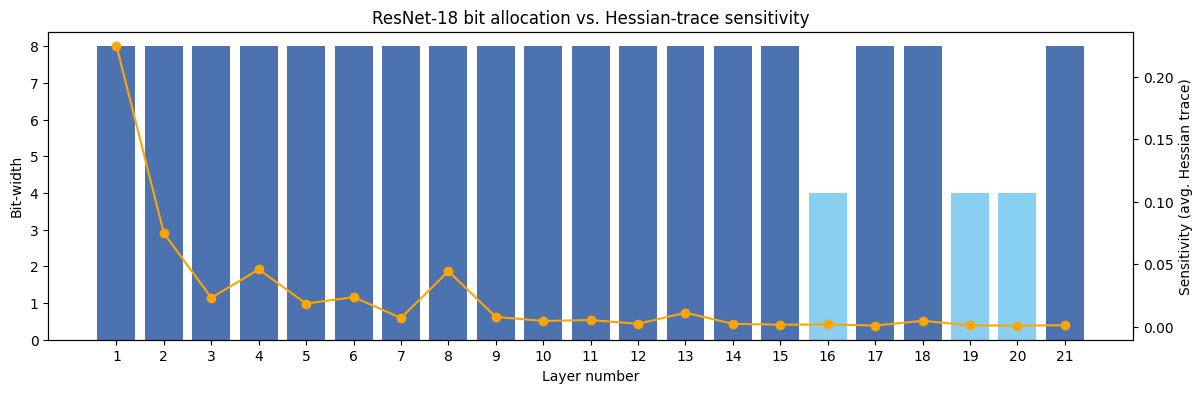

In [22]:
# Per-layer bit-width vs. sensitivity (compare to the paper's Figure I.1)
def plot_bit_assignment(bit_config, sensitivity_scores, title):
    names = layer_names
    bits = [bit_config[n] for n in names]
    scores = [sensitivity_scores[n] for n in names]

    fig, ax1 = plt.subplots(figsize=(14, 4))
    ax1.bar(range(len(names)), bits, color=["#4C72B0" if b == 8 else "#89CFF0" for b in bits])
    ax1.set_ylabel("Bit-width")
    ax1.set_xticks(range(len(names)))
    ax1.set_xticklabels(range(1, len(names) + 1))
    ax1.set_xlabel("Layer number")

    ax2 = ax1.twinx()
    ax2.plot(range(len(names)), scores, color="orange", marker="o")
    ax2.set_ylabel("Sensitivity (avg. Hessian trace)")

    plt.title(title)
    plt.show()

plot_bit_assignment(hessian_result["bit_config"], hessian_traces,
                    "ResNet-18 bit allocation vs. Hessian-trace sensitivity")

Sweeping size budget:   0%|          | 0/5 [00:00<?, ?it/s]

[Hessian trace (HAWQ-V3)] ILP status: Optimal


Mixed (Hessian trace (HAWQ-V3)):   0%|          | 0/79 [00:00<?, ?it/s]

[Hessian trace (HAWQ-V3)] ILP status: Optimal


Mixed (Hessian trace (HAWQ-V3)):   0%|          | 0/79 [00:00<?, ?it/s]

...

Mixed (Hessian trace (HAWQ-V3)):   0%|          | 0/79 [00:00<?, ?it/s]

[Hessian trace (HAWQ-V3)] ILP status: Optimal


Mixed (Hessian trace (HAWQ-V3)):   0%|          | 0/79 [00:00<?, ?it/s]

[Hessian trace (HAWQ-V3)] ILP status: Optimal


Mixed (Hessian trace (HAWQ-V3)):   0%|          | 0/79 [00:00<?, ?it/s]

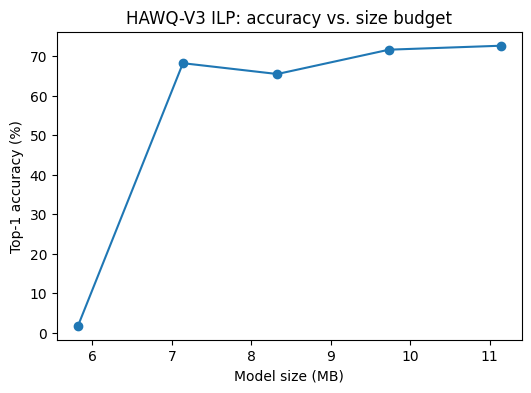

In [23]:
# Accuracy vs. model-size trade-off, sweeping the ILP's size budget
size_budgets = np.linspace(int4_size, int8_size, 5)
tradeoff = []
for budget in tqdm(size_budgets, desc="Sweeping size budget"):
    r = evaluate_sensitivity_metric("Hessian trace (HAWQ-V3)", omega, budget)
    tradeoff.append({"size_mb": r["size_mb"], "top1": r["top1"]})

tradeoff_df = pd.DataFrame(tradeoff)
plt.figure(figsize=(6, 4))
plt.plot(tradeoff_df["size_mb"], tradeoff_df["top1"], marker="o")
plt.xlabel("Model size (MB)")
plt.ylabel("Top-1 accuracy (%)")
plt.title("HAWQ-V3 ILP: accuracy vs. size budget")
plt.show()

In [24]:
# Compare our ILP's bit choices to HAWQ's official bit_config.py from the cloned repo
!find HAWQ -iname "bit_config*.py"

HAWQ/bit_config.py


# BONUS BONUS BONUS!!!!

RQNKUP's data-free sensitivity metrics: **excess kurtosis** (how outlier-heavy a
layer's weight distribution is) and **spectral rank** (how much structure/redundancy
a layer's weight matrix has). Neither uses any data or backprop -- they look only at
the trained weights themselves.

In [25]:
# Data-free sensitivity metrics: excess kurtosis and spectral rank
def excess_kurtosis(weight):
    w = weight.detach().flatten().float()
    mean = w.mean()
    std = w.std().clamp(min=1e-8)
    return ((((w - mean) / std) ** 4).mean() - 3.0).item()

def spectral_rank(weight, energy_threshold=0.99):
    """Effective rank: how many singular values are needed to capture
    `energy_threshold` of the total energy, normalized to [0, 1]."""
    out_ch = weight.shape[0]
    w2d = weight.detach().reshape(out_ch, -1).float()
    s = torch.linalg.svdvals(w2d)
    energy = torch.cumsum(s ** 2, dim=0) / (s ** 2).sum()
    rank = torch.searchsorted(energy, energy_threshold).item() + 1
    return rank / len(s)

kurtosis_scores, rank_scores = {}, {}
for name, info in tqdm(layer_inventory.items(), desc="Data-free metrics"):
    w = info["module"].weight
    kurtosis_scores[name] = excess_kurtosis(w)
    rank_scores[name] = spectral_rank(w)

# combine with the SAME quantization perturbation term used for Omega,
# so the comparison isolates the sensitivity metric, not the perturbation term
kurtosis_omega = {n: {b: kurtosis_scores[n] * quant_error_only[n][b] for b in BIT_CHOICES} for n in layer_names}
rank_omega     = {n: {b: rank_scores[n]     * quant_error_only[n][b] for b in BIT_CHOICES} for n in layer_names}

for name, om in [("Excess kurtosis (RQNKUP)", kurtosis_omega),
                 ("Spectral rank (RQNKUP)", rank_omega)]:
    results.append(evaluate_sensitivity_metric(name, om, mid_size_limit))

results_df = pd.DataFrame(results)[["method", "top1", "size_mb", "bops_g"]]
results_df

Data-free metrics:   0%|          | 0/21 [00:00<?, ?it/s]

[Excess kurtosis (RQNKUP)] ILP status: Optimal


Mixed (Excess kurtosis (RQNKUP)):   0%|          | 0/79 [00:00<?, ?it/s]

[Spectral rank (RQNKUP)] ILP status: Optimal


Mixed (Spectral rank (RQNKUP)):   0%|          | 0/79 [00:00<?, ?it/s]

,method,top1,size_mb,bops_g
0,Uniform INT4,1.76,5.818520,34.714419
1,Uniform INT8,72.61,11.138832,116.100694
2,Mixed (Hessian trace (HAWQ-V3)),65.45,8.326332,102.228034
3,Mixed (Top eigenvalue (HAWQ-V1)),65.13,8.474770,93.596156
4,Mixed (Quantization error only),65.45,8.326332,102.228034
5,Mixed (Random),63.95,8.326332,93.904437
6,Mixed (Excess kurtosis (RQNKUP)),68.87,8.326332,102.228034
7,Mixed (Spectral rank (RQNKUP)),65.45,8.326332,102.228034


In [26]:
check_acc = evaluate_top1(model, eval_loader, desc="FP32 re-check")
print(f"FP32 accuracy before quantization sweeps: {fp32_acc:.2f}%")
print(f"FP32 accuracy after quantization sweeps:  {check_acc:.2f}%")
assert abs(check_acc - fp32_acc) < 0.1, "Model was NOT fully restored to FP32!"


FP32 re-check:   0%|          | 0/79 [00:00<?, ?it/s]

FP32 accuracy before quantization sweeps: 72.62%
FP32 accuracy after quantization sweeps:  72.62%


In [27]:
for r in results:
    if "bit_config" not in r:
        continue
    int4_layers = [n for n, b in r["bit_config"].items() if b == 4]
    print(f"{r['method']:35s} -> {len(int4_layers)} INT4 layers: {int4_layers}")

Mixed (Hessian trace (HAWQ-V3))     -> 3 INT4 layers: ['features.stage4.unit1.body.conv1.conv', 'features.stage4.unit2.body.conv1.conv', 'features.stage4.unit2.body.conv2.conv']
Mixed (Top eigenvalue (HAWQ-V1))    -> 5 INT4 layers: ['features.stage2.unit2.body.conv2.conv', 'features.stage3.unit2.body.conv2.conv', 'features.stage4.unit1.body.conv2.conv', 'features.stage4.unit1.identity_conv.conv', 'features.stage4.unit2.body.conv2.conv']
Mixed (Quantization error only)     -> 3 INT4 layers: ['features.stage4.unit1.body.conv1.conv', 'features.stage4.unit2.body.conv1.conv', 'features.stage4.unit2.body.conv2.conv']
Mixed (Random)                      -> 4 INT4 layers: ['features.stage3.unit1.body.conv2.conv', 'features.stage3.unit2.body.conv1.conv', 'features.stage4.unit2.body.conv1.conv', 'features.stage4.unit2.body.conv2.conv']
Mixed (Excess kurtosis (RQNKUP))    -> 3 INT4 layers: ['features.stage4.unit1.body.conv1.conv', 'features.stage4.unit1.body.conv2.conv', 'features.stage4.unit2.bo

In [28]:
# Save all results to Drive
results_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_results.csv")
results_df.to_csv(results_path, index=False)
print("Saved results to", results_path)

Saved results to /content/drive/MyDrive/rqnkup/hawqv3/results/resnet18_results.csv
